In [2]:
# =====================
# DAY 4 - PERFORMANCE ANALYTICS
# Bluestock MF Analytics
# =====================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import sqlite3
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 6)
sns.set_theme(style="whitegrid")
os.makedirs("../charts", exist_ok=True)

# Data load karo
nav_df = pd.read_csv("../data/processed/clean_nav.csv", parse_dates=['date'])
perf_df = pd.read_csv("../data/processed/clean_performance.csv")
fund_df = pd.read_csv("../data/raw/01_fund_master.csv")
benchmark_df = pd.read_csv("../data/raw/10_benchmark_indices.csv", parse_dates=['date'])

print("✅ All data loaded!")
print(f"  NAV History  : {nav_df.shape}")
print(f"  Performance  : {perf_df.shape}")
print(f"  Fund Master  : {fund_df.shape}")
print(f"  Benchmark    : {benchmark_df.shape}")

✅ All data loaded!
  NAV History  : (64320, 3)
  Performance  : (40, 19)
  Fund Master  : (40, 15)
  Benchmark    : (8050, 3)


In [3]:
# =====================
# TASK 1 - DAILY RETURNS
# =====================

# Fund names merge karo
nav_merged = nav_df.merge(
    fund_df[['amfi_code', 'scheme_name', 'sub_category', 'plan']],
    on='amfi_code', how='left'
)

# Sort karo
nav_merged = nav_merged.sort_values(['amfi_code', 'date']).reset_index(drop=True)

# Daily return calculate karo: nav_t / nav_t-1 - 1
nav_merged['daily_return'] = nav_merged.groupby('amfi_code')['nav'].pct_change()

# Pehle row ka return NaN hoga — drop karo
nav_returns = nav_merged.dropna(subset=['daily_return']).copy()

# Annualised return per fund
def annualised_return(returns):
    n = len(returns)
    return (1 + returns).prod() ** (252 / n) - 1

ann_returns = nav_returns.groupby('amfi_code')['daily_return'].apply(
    annualised_return).reset_index()
ann_returns.columns = ['amfi_code', 'annualised_return_pct']
ann_returns['annualised_return_pct'] = (ann_returns['annualised_return_pct'] * 100).round(2)

# Fund names add karo
ann_returns = ann_returns.merge(
    fund_df[['amfi_code', 'scheme_name', 'sub_category']], on='amfi_code', how='left')

print("✅ Daily Returns Computed!")
print(f"Total return rows: {len(nav_returns):,}")
print(f"\nAnnualised Returns (Top 10):")
print(ann_returns.sort_values('annualised_return_pct', ascending=False).head(10)[
    ['scheme_name', 'annualised_return_pct']].to_string(index=False))

# Save karo
nav_returns.to_csv("../data/processed/returns_computed.csv", index=False)
ann_returns.to_csv("../data/processed/annualised_returns.csv", index=False)
print("\n✅ Saved: returns_computed.csv, annualised_returns.csv")

✅ Daily Returns Computed!
Total return rows: 64,280

Annualised Returns (Top 10):
                                       scheme_name  annualised_return_pct
          ICICI Pru Midcap Fund - Regular - Growth                  21.64
        SBI Small Cap Fund - Regular Plan - Growth                  21.38
             DSP Small Cap Fund - Regular - Growth                  21.29
     Mirae Asset Tax Saver Fund - Regular - Growth                  21.08
     Mirae Asset Large Cap Fund - Regular - Growth                  20.46
            Kotak Flexicap Fund - Regular - Growth                  20.42
HDFC Mid-Cap Opportunities Fund - Regular - Growth                  19.92
                DSP Midcap Fund - Regular - Growth                  19.58
               Axis Midcap Fund - Regular - Growth                  18.71
         SBI Bluechip Fund - Regular Plan - Growth                  17.16

✅ Saved: returns_computed.csv, annualised_returns.csv


In [4]:
# =====================
# TASK 2 - CAGR CALCULATION
# =====================

def compute_cagr(nav_series, years):
    """CAGR = (NAV_end / NAV_start) ^ (1/years) - 1"""
    nav_series = nav_series.sort_values('date')
    nav_end = nav_series['nav'].iloc[-1]
    
    # Start date = end date minus years
    cutoff = nav_series['date'].iloc[-1] - pd.DateOffset(years=years)
    nav_start_row = nav_series[nav_series['date'] >= cutoff]
    
    if len(nav_start_row) < 30:  # Enough data nahi hai
        return None
    
    nav_start = nav_start_row['nav'].iloc[0]
    cagr = (nav_end / nav_start) ** (1 / years) - 1
    return round(cagr * 100, 2)

cagr_results = []

for code, group in nav_df.groupby('amfi_code'):
    row = {'amfi_code': code}
    row['cagr_1yr'] = compute_cagr(group, 1)
    row['cagr_3yr'] = compute_cagr(group, 3)
    row['cagr_5yr'] = compute_cagr(group, 4)  # Data ~4 yrs hai
    cagr_results.append(row)

cagr_df = pd.DataFrame(cagr_results)
cagr_df = cagr_df.merge(
    fund_df[['amfi_code', 'scheme_name', 'sub_category', 'fund_house']],
    on='amfi_code', how='left')

print("✅ CAGR Computed!")
print(f"\nTop 10 Funds by 3yr CAGR:")
print(cagr_df.sort_values('cagr_3yr', ascending=False).head(10)[
    ['scheme_name', 'cagr_1yr', 'cagr_3yr', 'cagr_5yr']].to_string(index=False))

cagr_df.to_csv("../data/processed/cagr_report.csv", index=False)
print("\n✅ Saved: cagr_report.csv")

✅ CAGR Computed!

Top 10 Funds by 3yr CAGR:
                                       scheme_name  cagr_1yr  cagr_3yr  cagr_5yr
               Axis Midcap Fund - Regular - Growth     22.26     35.11     30.48
     Mirae Asset Large Cap Fund - Regular - Growth     20.36     34.00     28.84
         ICICI Pru Bluechip Fund - Direct - Growth     13.06     32.49     23.10
HDFC Mid-Cap Opportunities Fund - Regular - Growth     53.23     32.44     37.24
          ICICI Pru Midcap Fund - Regular - Growth     29.60     31.78     26.78
         SBI Bluechip Fund - Regular Plan - Growth     60.44     30.46     31.00
            Kotak Flexicap Fund - Regular - Growth     26.66     29.58     37.08
     Mirae Asset Tax Saver Fund - Regular - Growth     39.75     29.18     31.11
     ABSL Frontline Equity Fund - Regular - Growth     47.92     28.97     26.65
             DSP Small Cap Fund - Regular - Growth     65.14     27.00     35.48

✅ Saved: cagr_report.csv


✅ Sharpe Ratio Computed!

Top 10 Funds by Sharpe Ratio:
                                       scheme_name  sharpe_ratio
     Mirae Asset Large Cap Fund - Regular - Growth        1.0682
            Kotak Flexicap Fund - Regular - Growth        0.9656
     Mirae Asset Tax Saver Fund - Regular - Growth        0.9190
          ICICI Pru Midcap Fund - Regular - Growth        0.8833
         SBI Bluechip Fund - Regular Plan - Growth        0.8610
                DSP Midcap Fund - Regular - Growth        0.8329
HDFC Mid-Cap Opportunities Fund - Regular - Growth        0.8083
    Nippon India Large Cap Fund - Regular - Growth        0.7589
               Axis Midcap Fund - Regular - Growth        0.7305
     ABSL Frontline Equity Fund - Regular - Growth        0.7174


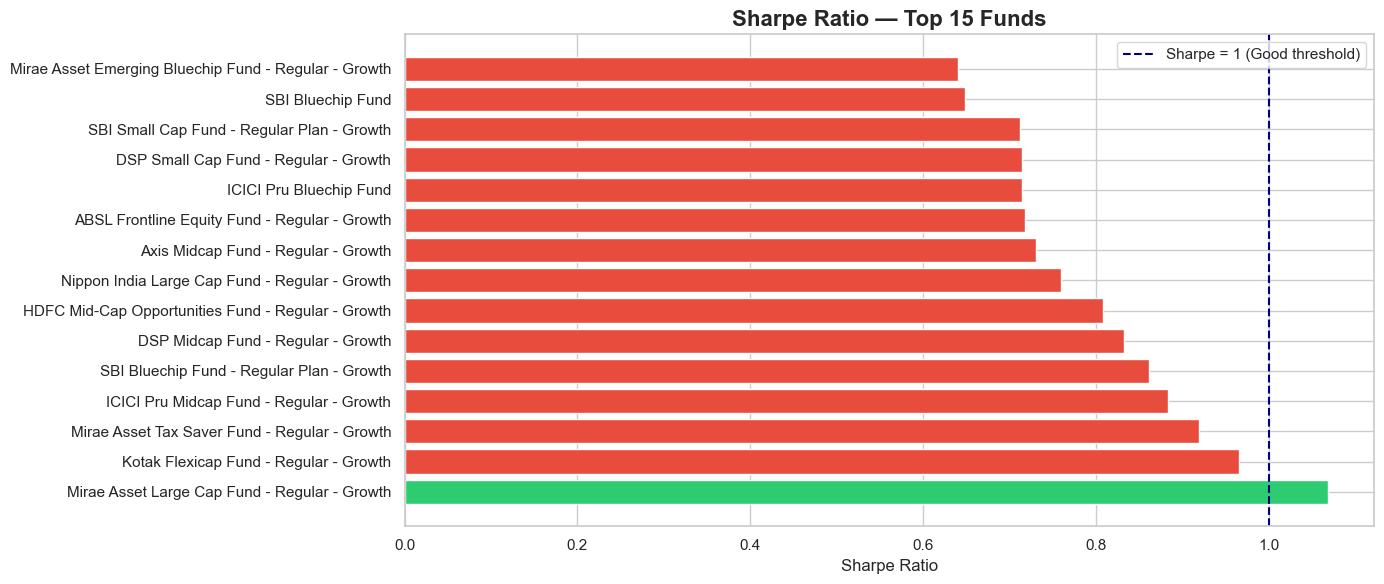

✅ Saved: sharpe_values.csv + chart


In [5]:
# =====================
# TASK 3 - SHARPE RATIO
# =====================

# Rf = 6.5% annual = per day
RF_ANNUAL = 0.065
RF_DAILY = RF_ANNUAL / 252

def compute_sharpe(returns):
    excess = returns - RF_DAILY
    if excess.std() == 0:
        return None
    return round((excess.mean() / excess.std()) * np.sqrt(252), 4)

sharpe_df = nav_returns.groupby('amfi_code')['daily_return'].apply(
    compute_sharpe).reset_index()
sharpe_df.columns = ['amfi_code', 'sharpe_ratio']

sharpe_df = sharpe_df.merge(
    fund_df[['amfi_code', 'scheme_name', 'sub_category', 'fund_house']],
    on='amfi_code', how='left')

print("✅ Sharpe Ratio Computed!")
print(f"\nTop 10 Funds by Sharpe Ratio:")
print(sharpe_df.sort_values('sharpe_ratio', ascending=False).head(10)[
    ['scheme_name', 'sharpe_ratio']].to_string(index=False))

# Chart banao
fig, ax = plt.subplots(figsize=(14, 6))
top_sharpe = sharpe_df.sort_values('sharpe_ratio', ascending=False).head(15)
bars = ax.barh(top_sharpe['scheme_name'].str.replace(' - Direct Plan - Growth', '').str.replace(' - Direct - Growth', ''),
               top_sharpe['sharpe_ratio'],
               color=['#2ecc71' if x > 1 else '#e74c3c' for x in top_sharpe['sharpe_ratio']])
ax.axvline(x=1, color='navy', linestyle='--', label='Sharpe = 1 (Good threshold)')
ax.set_title('Sharpe Ratio — Top 15 Funds', fontsize=16, fontweight='bold')
ax.set_xlabel('Sharpe Ratio')
ax.legend()
plt.tight_layout()
plt.savefig('../charts/10_sharpe_ratio.png', dpi=150)
plt.show()

sharpe_df.to_csv("../data/processed/sharpe_values.csv", index=False)
print("✅ Saved: sharpe_values.csv + chart")

In [6]:
# =====================
# TASK 4 - SORTINO RATIO
# =====================

def compute_sortino(returns):
    excess = returns - RF_DAILY
    # Sirf negative return days ka std
    downside = returns[returns < 0]
    if len(downside) < 5 or downside.std() == 0:
        return None
    downside_std = downside.std() * np.sqrt(252)
    ann_excess = excess.mean() * 252
    return round(ann_excess / downside_std, 4)

sortino_df = nav_returns.groupby('amfi_code')['daily_return'].apply(
    compute_sortino).reset_index()
sortino_df.columns = ['amfi_code', 'sortino_ratio']

sortino_df = sortino_df.merge(
    fund_df[['amfi_code', 'scheme_name', 'sub_category']],
    on='amfi_code', how='left')

print("✅ Sortino Ratio Computed!")
print(f"\nTop 10 Funds by Sortino Ratio:")
print(sortino_df.sort_values('sortino_ratio', ascending=False).head(10)[
    ['scheme_name', 'sortino_ratio']].to_string(index=False))

sortino_df.to_csv("../data/processed/sortino_values.csv", index=False)
print("✅ Saved: sortino_values.csv")

✅ Sortino Ratio Computed!

Top 10 Funds by Sortino Ratio:
                                       scheme_name  sortino_ratio
     Mirae Asset Large Cap Fund - Regular - Growth         1.4907
            Kotak Flexicap Fund - Regular - Growth         1.4795
     Mirae Asset Tax Saver Fund - Regular - Growth         1.3528
         SBI Bluechip Fund - Regular Plan - Growth         1.2915
          ICICI Pru Midcap Fund - Regular - Growth         1.2858
                DSP Midcap Fund - Regular - Growth         1.1678
HDFC Mid-Cap Opportunities Fund - Regular - Growth         1.1442
    Nippon India Large Cap Fund - Regular - Growth         1.0989
        SBI Small Cap Fund - Regular Plan - Growth         1.0673
         ICICI Pru Bluechip Fund - Direct - Growth         1.0640
✅ Saved: sortino_values.csv


In [9]:
# =====================
# TASK 5 - ALPHA & BETA
# =====================

# Benchmark returns nikalo (Nifty 100)
benchmark_df = benchmark_df.sort_values('date')
benchmark_df['bm_return'] = benchmark_df.groupby('index_name')['close_value'].pct_change()

nifty100 = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'][
    ['date', 'bm_return']].dropna()

print(f"Nifty 100 data points: {len(nifty100)}")
print(nifty100.head())

alpha_beta_results = []

for code, group in nav_returns.groupby('amfi_code'):
    group = group[['date', 'daily_return']].dropna()
    
    # Benchmark se merge karo on date
    merged = group.merge(nifty100, on='date', how='inner')
    
    if len(merged) < 60:
        alpha_beta_results.append({
            'amfi_code': code, 'alpha': None, 'beta': None, 'r_squared': None
        })
        continue
    
    # OLS regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['bm_return'], merged['daily_return'])
    
    alpha_beta_results.append({
        'amfi_code': code,
        'alpha': round(intercept * 252 * 100, 4),
        'beta': round(slope, 4),
        'r_squared': round(r_value ** 2, 4)
    })

ab_df = pd.DataFrame(alpha_beta_results)
ab_df = ab_df.merge(
    fund_df[['amfi_code', 'scheme_name', 'sub_category', 'fund_house']],
    on='amfi_code', how='left')

print("\n✅ Alpha & Beta Computed!")
print(f"\nTop 10 Funds by Alpha:")
print(ab_df.sort_values('alpha', ascending=False).head(10)[
    ['scheme_name', 'alpha', 'beta', 'r_squared']].to_string(index=False))

ab_df.to_csv("../data/processed/alpha_beta.csv", index=False)
print("\n✅ Saved: alpha_beta.csv")

Nifty 100 data points: 1149
           date  bm_return
1151 2022-01-04  -0.013540
1152 2022-01-05   0.004003
1153 2022-01-06  -0.002935
1154 2022-01-07   0.006150
1155 2022-01-10  -0.008351

✅ Alpha & Beta Computed!

Top 10 Funds by Alpha:
                                       scheme_name   alpha    beta  r_squared
        SBI Small Cap Fund - Regular Plan - Growth 30.3370 -0.0232     0.0001
             DSP Small Cap Fund - Regular - Growth 30.0579  0.0115     0.0000
          ICICI Pru Midcap Fund - Regular - Growth 29.2636  0.0005     0.0000
     Mirae Asset Tax Saver Fund - Regular - Growth 28.2704  0.0181     0.0002
            Kotak Flexicap Fund - Regular - Growth 27.3305 -0.0228     0.0003
HDFC Mid-Cap Opportunities Fund - Regular - Growth 27.1954  0.0051     0.0000
     Mirae Asset Large Cap Fund - Regular - Growth 26.9838  0.0237     0.0005
                DSP Midcap Fund - Regular - Growth 26.5986 -0.0025     0.0000
               Axis Midcap Fund - Regular - Growth 26.0767

In [8]:
# Benchmark CSV columns check karo
print(benchmark_df.columns.tolist())
print(benchmark_df.head())

['date', 'index_name', 'close_value']
           date       index_name  close_value
0    2022-01-03          NIFTY50     17492.79
5750 2022-01-03    CRISIL_LIQUID      2281.51
2300 2022-01-03  NIFTY_MIDCAP150      9721.79
6900 2022-01-03      CRISIL_GILT      1451.06
1150 2022-01-03         NIFTY100     17778.24


✅ Maximum Drawdown Computed!

Funds with Worst Drawdown:
                                   scheme_name  max_drawdown_pct
     SBI Small Cap Fund - Direct Plan - Growth            -52.57
        Axis Small Cap Fund - Regular - Growth            -51.68
        ABSL Small Cap Fund - Regular - Growth            -35.45
         DSP Small Cap Fund - Regular - Growth            -31.17
    SBI Small Cap Fund - Regular Plan - Growth            -28.71
           UTI Mid Cap Fund - Regular - Growth            -28.00
     HDFC Top 100 Fund - Regular Plan - Growth            -24.73
 Kotak Emerging Equity Fund - Regular - Growth            -24.00
Nippon India Small Cap Fund - Regular - Growth            -23.34
          Axis Bluechip Fund - Direct - Growth            -21.75


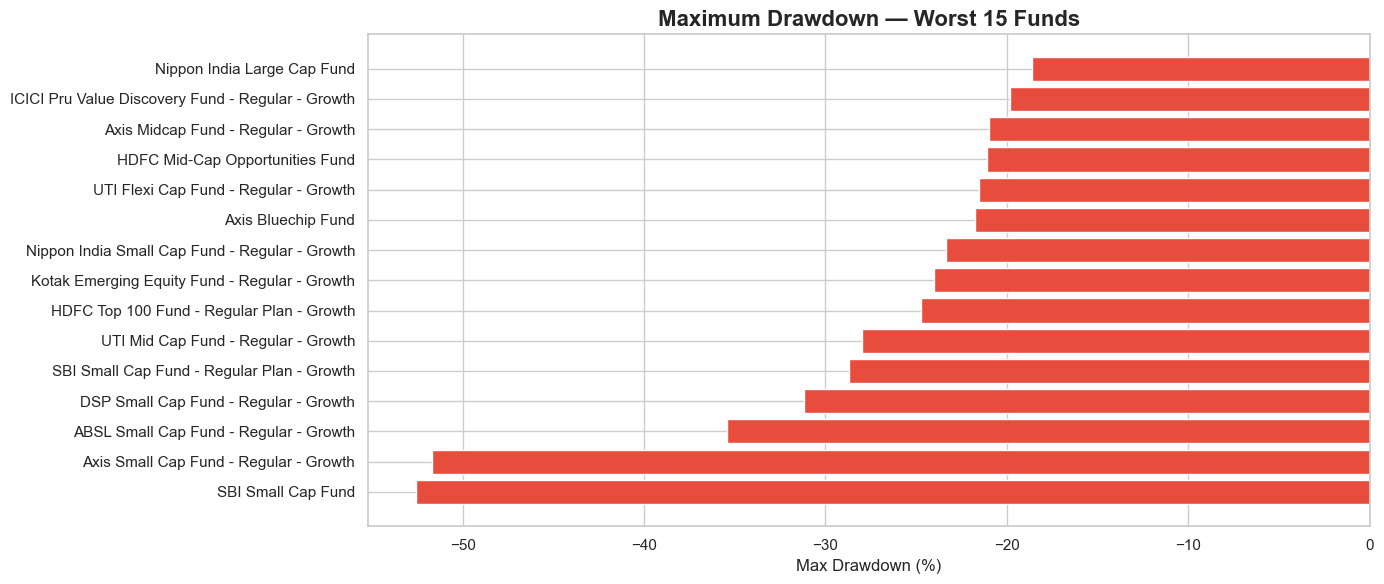

✅ Saved: max_drawdown.csv + chart


In [10]:
# =====================
# TASK 6 - MAXIMUM DRAWDOWN
# =====================

def compute_max_drawdown(nav_series):
    rolling_max = nav_series.cummax()
    drawdown = nav_series / rolling_max - 1
    return round(drawdown.min() * 100, 2)  # Percentage mein

mdd_df = nav_df.sort_values(['amfi_code', 'date']).groupby(
    'amfi_code')['nav'].apply(compute_max_drawdown).reset_index()
mdd_df.columns = ['amfi_code', 'max_drawdown_pct']

mdd_df = mdd_df.merge(
    fund_df[['amfi_code', 'scheme_name', 'sub_category']],
    on='amfi_code', how='left')

print("✅ Maximum Drawdown Computed!")
print(f"\nFunds with Worst Drawdown:")
print(mdd_df.sort_values('max_drawdown_pct').head(10)[
    ['scheme_name', 'max_drawdown_pct']].to_string(index=False))

# Chart
fig, ax = plt.subplots(figsize=(14, 6))
mdd_sorted = mdd_df.sort_values('max_drawdown_pct').head(15)
ax.barh(mdd_sorted['scheme_name'].str.replace(' - Direct Plan - Growth', '').str.replace(' - Direct - Growth', ''),
        mdd_sorted['max_drawdown_pct'],
        color='#e74c3c')
ax.set_title('Maximum Drawdown — Worst 15 Funds', fontsize=16, fontweight='bold')
ax.set_xlabel('Max Drawdown (%)')
plt.tight_layout()
plt.savefig('../charts/11_max_drawdown.png', dpi=150)
plt.show()

mdd_df.to_csv("../data/processed/max_drawdown.csv", index=False)
print("✅ Saved: max_drawdown.csv + chart")

✅ Fund Scorecard Ready!

🏆 TOP 10 FUNDS — COMPOSITE SCORE:
                                           scheme_name  cagr_3yr  sharpe_ratio    alpha  expense_ratio_pct  composite_score
1             ICICI Pru Midcap Fund - Regular - Growth     31.78        0.8833  29.2636               1.36            85.12
2                  Axis Midcap Fund - Regular - Growth     35.11        0.7305  26.0767               1.38            82.00
3   HDFC Mid-Cap Opportunities Fund - Regular - Growth     32.44        0.8083  27.1954               1.38            80.50
4        Mirae Asset Large Cap Fund - Regular - Growth     34.00        1.0682  26.9838               1.46            80.00
5               Kotak Flexicap Fund - Regular - Growth     29.58        0.9656  27.3305               1.45            78.25
6           SBI Small Cap Fund - Regular Plan - Growth     26.67        0.7117  30.3370               1.43            75.75
7                DSP Small Cap Fund - Regular - Growth     27.00        0

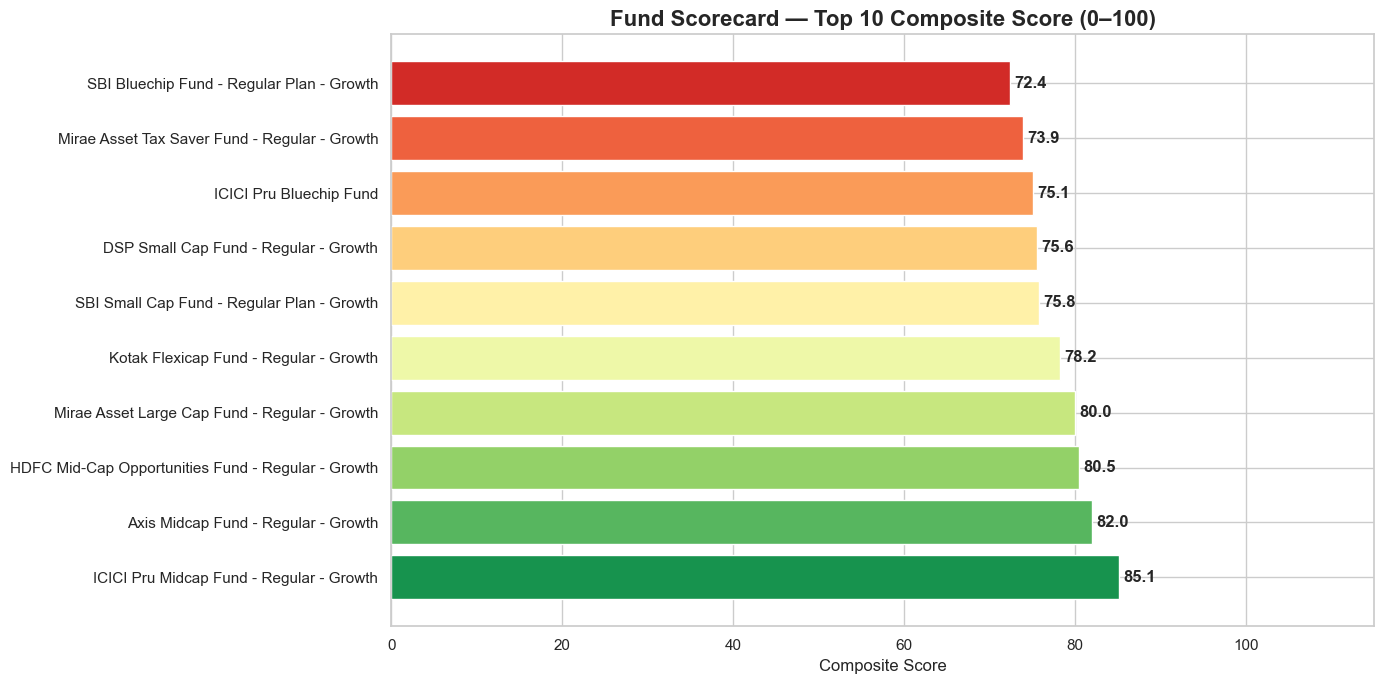

✅ Saved: fund_scorecard.csv + chart


In [11]:
# =====================
# TASK 7 - FUND SCORECARD
# =====================

# Sab metrics ek table mein merge karo
scorecard = fund_df[['amfi_code', 'scheme_name', 'fund_house',
                      'sub_category', 'expense_ratio_pct']].copy()

scorecard = scorecard.merge(cagr_df[['amfi_code', 'cagr_3yr']], on='amfi_code', how='left')
scorecard = scorecard.merge(sharpe_df[['amfi_code', 'sharpe_ratio']], on='amfi_code', how='left')
scorecard = scorecard.merge(ab_df[['amfi_code', 'alpha']], on='amfi_code', how='left')
scorecard = scorecard.merge(mdd_df[['amfi_code', 'max_drawdown_pct']], on='amfi_code', how='left')

# Rank karo — higher is better
scorecard['rank_3yr']     = scorecard['cagr_3yr'].rank(ascending=True, pct=True) * 100
scorecard['rank_sharpe']  = scorecard['sharpe_ratio'].rank(ascending=True, pct=True) * 100
scorecard['rank_alpha']   = scorecard['alpha'].rank(ascending=True, pct=True) * 100
# Expense ratio — lower is better (inverse rank)
scorecard['rank_expense'] = scorecard['expense_ratio_pct'].rank(ascending=False, pct=True) * 100
# Max Drawdown — lower magnitude is better (inverse rank)
scorecard['rank_mdd']     = scorecard['max_drawdown_pct'].rank(ascending=False, pct=True) * 100

# Composite Score
scorecard['composite_score'] = (
    0.30 * scorecard['rank_3yr'] +
    0.25 * scorecard['rank_sharpe'] +
    0.20 * scorecard['rank_alpha'] +
    0.15 * scorecard['rank_expense'] +
    0.10 * scorecard['rank_mdd']
).round(2)

# Final sort
scorecard = scorecard.sort_values('composite_score', ascending=False).reset_index(drop=True)
scorecard.index += 1  # Rank 1 se shuru karo

print("✅ Fund Scorecard Ready!")
print(f"\n🏆 TOP 10 FUNDS — COMPOSITE SCORE:")
print(scorecard[['scheme_name', 'cagr_3yr', 'sharpe_ratio',
                  'alpha', 'expense_ratio_pct', 'composite_score']].head(10).to_string())

# Chart
fig, ax = plt.subplots(figsize=(14, 7))
top10 = scorecard.head(10)
bars = ax.barh(
    top10['scheme_name'].str.replace(' - Direct Plan - Growth', '').str.replace(' - Direct - Growth', ''),
    top10['composite_score'],
    color=sns.color_palette('RdYlGn', 10)[::-1])

for bar, score in zip(bars, top10['composite_score']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', fontweight='bold')

ax.set_title('Fund Scorecard — Top 10 Composite Score (0–100)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Composite Score')
ax.set_xlim(0, 115)
plt.tight_layout()
plt.savefig('../charts/12_fund_scorecard.png', dpi=150)
plt.show()

scorecard.to_csv("../data/processed/fund_scorecard.csv")
print("✅ Saved: fund_scorecard.csv + chart")

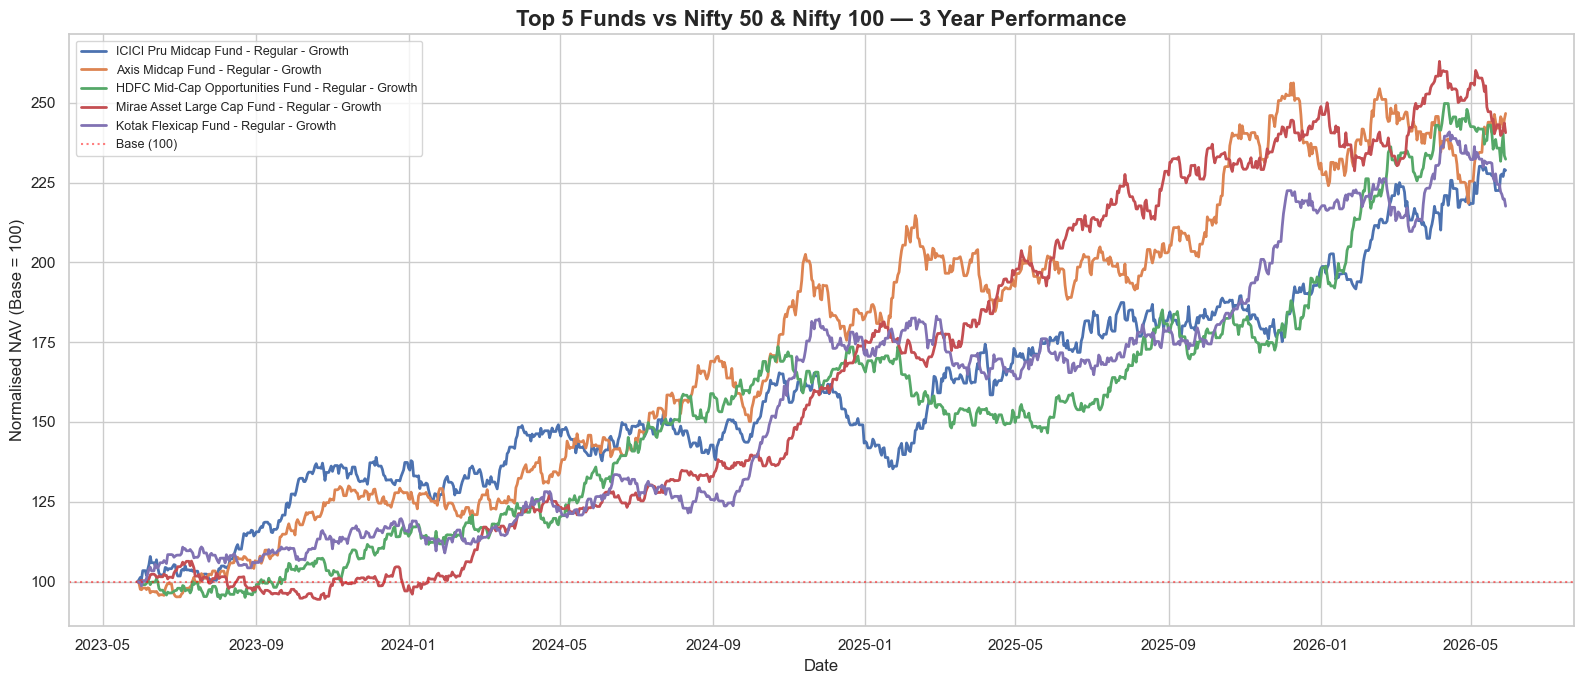


📊 Tracking Error vs Nifty 100:
  ICICI Pru Midcap Fund - Regular - Growth: 23.20%
  Axis Midcap Fund - Regular - Growth: 23.77%
  HDFC Mid-Cap Opportunities Fund - Regula: 22.87%
  Mirae Asset Large Cap Fund - Regular - G: 18.97%
  Kotak Flexicap Fund - Regular - Growth: 20.64%

✅ Benchmark comparison chart saved!


In [12]:
# =====================
# TASK 8 - BENCHMARK COMPARISON
# =====================

# Top 5 funds from scorecard
top5_codes = scorecard.head(5)['amfi_code'].tolist()
top5_names = scorecard.head(5).set_index('amfi_code')['scheme_name'].to_dict()

# 3 year data filter karo
cutoff = nav_df['date'].max() - pd.DateOffset(years=3)
nav_3yr = nav_df[nav_df['date'] >= cutoff]

# Normalise karo — sab 100 se shuru
fig, ax = plt.subplots(figsize=(16, 7))

for code in top5_codes:
    fund_nav = nav_3yr[nav_3yr['amfi_code'] == code].sort_values('date')
    if len(fund_nav) < 10:
        continue
    normalised = fund_nav['nav'] / fund_nav['nav'].iloc[0] * 100
    label = top5_names.get(code, str(code))
    label = label.replace(' - Direct Plan - Growth', '').replace(' - Direct - Growth', '')
    ax.plot(fund_nav['date'], normalised, linewidth=2, label=label)

# Benchmark plot karo
for idx_name, color, style in [('Nifty 50', 'black', '-'),
                                 ('Nifty 100', 'grey', '--')]:
    bm = benchmark_df[benchmark_df['index_name'] == idx_name]
    bm = bm[bm['date'] >= cutoff].sort_values('date')
    if len(bm) > 0:
        normalised_bm = bm['close'] / bm['close'].iloc[0] * 100
        ax.plot(bm['date'], normalised_bm, linewidth=2.5,
                color=color, linestyle=style, label=idx_name)

ax.axhline(y=100, color='red', linestyle=':', alpha=0.5, label='Base (100)')
ax.set_title('Top 5 Funds vs Nifty 50 & Nifty 100 — 3 Year Performance',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Normalised NAV (Base = 100)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../charts/13_benchmark_comparison.png', dpi=150)
plt.show()

# Tracking Error calculate karo
print("\n📊 Tracking Error vs Nifty 100:")
nifty100_ret = nifty100.set_index('date')['bm_return']

for code in top5_codes:
    fund_ret = nav_returns[nav_returns['amfi_code'] == code].set_index('date')['daily_return']
    aligned = pd.concat([fund_ret, nifty100_ret], axis=1).dropna()
    if len(aligned) > 30:
        tracking_error = (aligned.iloc[:, 0] - aligned.iloc[:, 1]).std() * np.sqrt(252) * 100
        name = top5_names.get(code, str(code)).replace(' - Direct Plan - Growth', '')
        print(f"  {name[:40]}: {tracking_error:.2f}%")

print("\n✅ Benchmark comparison chart saved!")

In [13]:
import subprocess
result = subprocess.run(
    ['git', 'add', '.'],
    capture_output=True, text=True, cwd='../')
print(result.stdout)
print("Run in terminal: git commit -m 'Day 4: Performance metrics complete' && git push")


Run in terminal: git commit -m 'Day 4: Performance metrics complete' && git push
